<a href="https://colab.research.google.com/github/fayazanalytics/Amazon-Sales-Analysis/blob/main/Health_Risk_Analytics_Multiple_Linear_Regression_in_Action.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Generating a synthetic dataset for health analysis
np.random.seed(42)
data = {
    'Age': np.random.randint(20, 80, 200),
    'BMI': np.random.uniform(18.5, 35, 200),
    'BloodPressure': np.random.randint(90, 180, 200),
    'Cholesterol': np.random.randint(150, 300, 200),
    'HeartRate': np.random.randint(60, 120, 200),
    'SmokingStatus': np.random.randint(0, 2, 200),  # 0: Non-smoker, 1: Smoker
    'ExerciseHoursPerWeek': np.random.uniform(0, 10, 200),
    'HospitalReadmissionRate': np.random.uniform(0, 1, 200)  # Target variable
}

In [ ]:
# Creating DataFrame
df = pd.DataFrame(data)

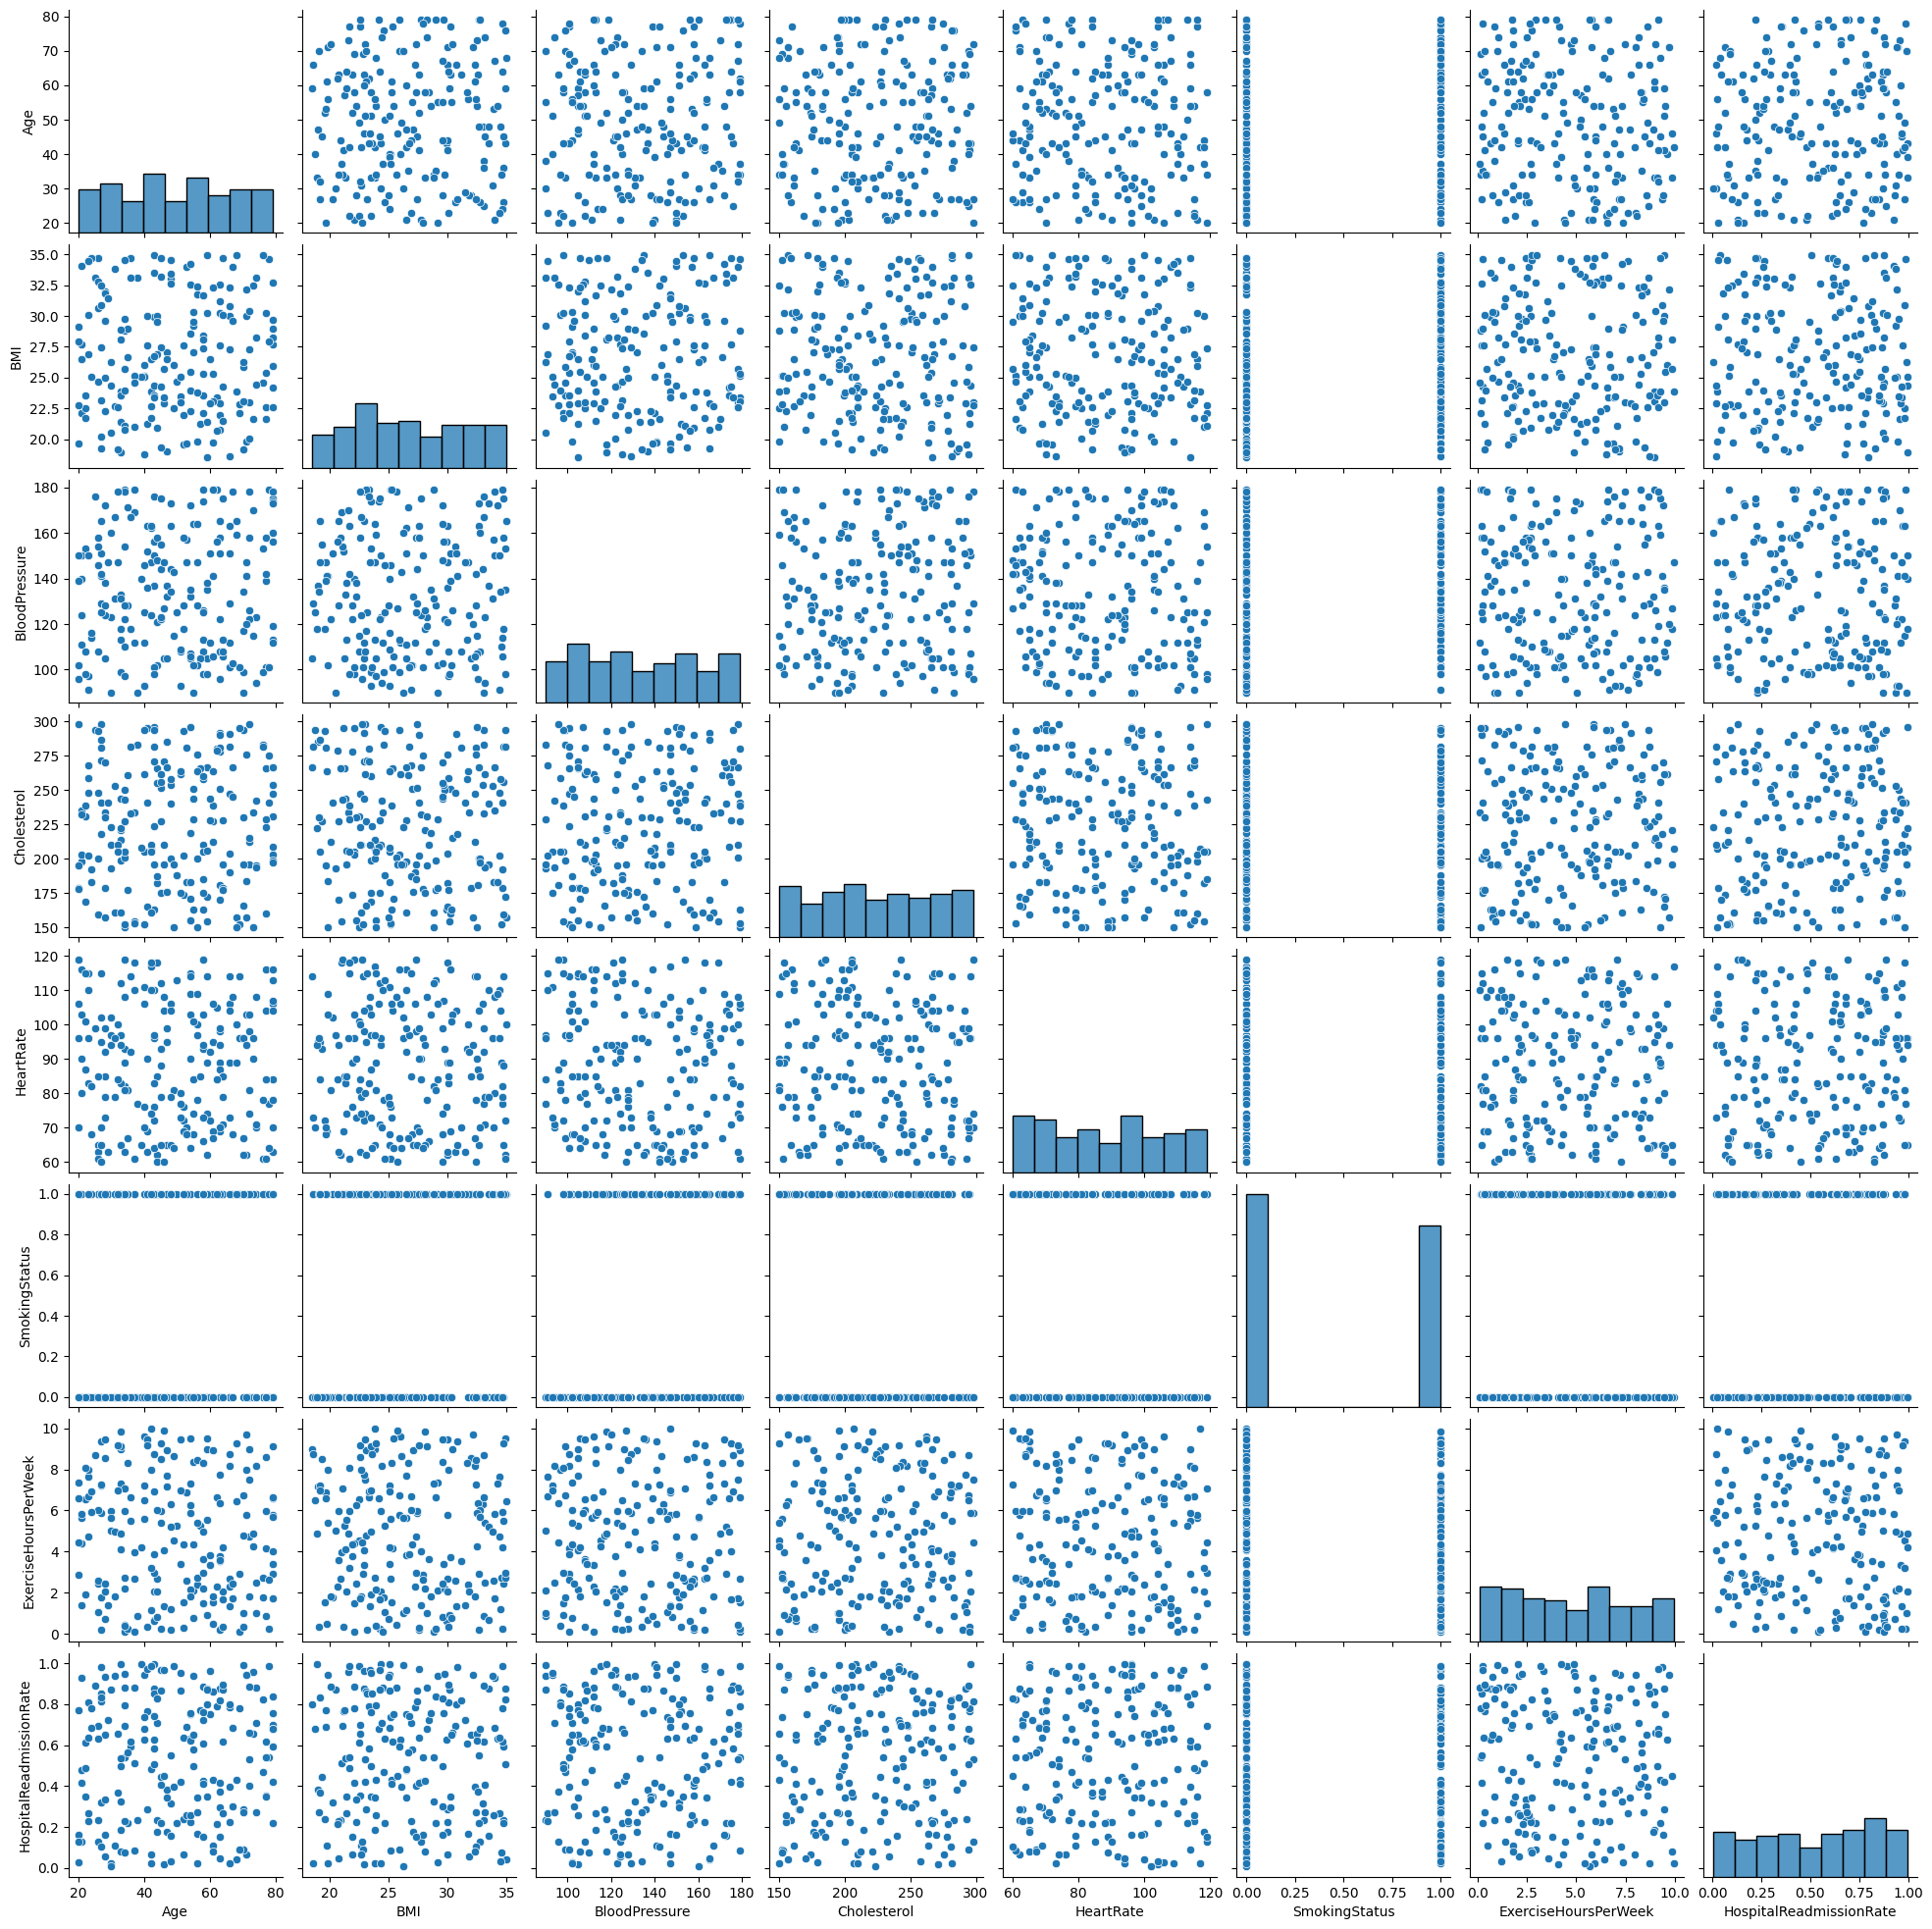

In [ ]:

# Exploratory Data Analysis (EDA)
sns.pairplot(df)
plt.show()

In [ ]:
# Splitting Data
X = df.drop(columns=['HospitalReadmissionRate'])
y = df['HospitalReadmissionRate']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Training Multiple Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Predictions
y_pred = model.predict(X_test)

In [ ]:
# Model Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [ ]:
print(f'Mean Squared Error: {mse}')
print(f'R² Score: {r2}')

Mean Squared Error: 0.09512642786786615
R² Score: -0.027188700688000056


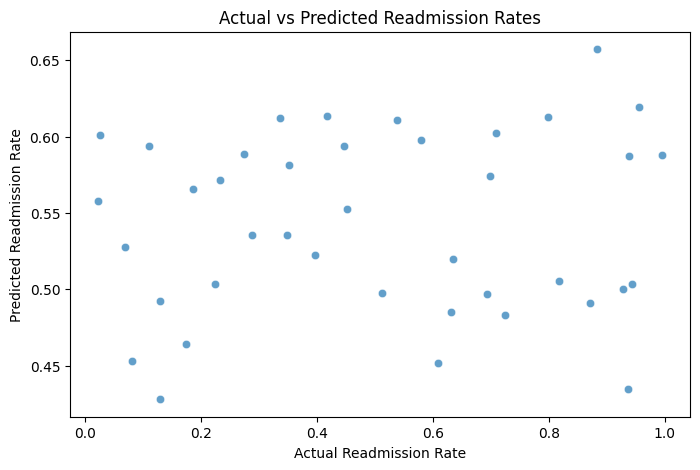

In [ ]:
# Visualizing Predictions
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.xlabel("Actual Readmission Rate")
plt.ylabel("Predicted Readmission Rate")
plt.title("Actual vs Predicted Readmission Rates")
plt.show()

In [ ]:

# Displaying Feature Importance
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coefficients.sort_values(by='Coefficient', ascending=False))

                      Coefficient
Age                      0.000698
Cholesterol              0.000223
BloodPressure           -0.000134
HeartRate               -0.000443
ExerciseHoursPerWeek    -0.006484
BMI                     -0.006950
SmokingStatus           -0.078985
